In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Уровень значимости
alpha = 0.05

def pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]

def linreg_coef(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    a = (np.sum(x*y) - n*x_mean*y_mean) / (np.sum(x**2) - n*x_mean**2)
    b = y_mean - a*x_mean
    return a, b

def t_test_corr(r, n):
    t = abs(r) * np.sqrt((n - 2) / (1 - r**2))
    t_critical = stats.t.ppf(1 - alpha/2, n-2)
    return t, t_critical, t > t_critical

def f_test_adequacy(x, y, a, b):
    n = len(x)
    y_pred = a*x + b
    S_mod2 = np.sum((y - y_pred)**2) / (n - 2)
    S_total2 = np.sum((y - np.mean(y))**2) / (n - 1)
    F = max(S_mod2, S_total2) / min(S_mod2, S_total2)
    F_critical = stats.f.ppf(1 - alpha, n-2, n-1)
    return F, F_critical, F > F_critical

def significance_coefs(x, y, a, b, S_mod):
    n = len(x)
    sigma_x = np.std(x, ddof=1)
    m_a = S_mod / (sigma_x * np.sqrt(n))
    m_b = (S_mod * np.sqrt(np.sum(x**2))) / (sigma_x * n)
    # t-stats
    T_a = a / m_a
    T_b = b / m_b
    t_critical = stats.t.ppf(1 - alpha/2, n-2)
    return (T_a, T_b, t_critical, 
            abs(T_a) > t_critical, abs(T_b) > t_critical,
            m_a, m_b)

def conf_intervals(a, b, m_a, m_b, n):
    t_val = stats.t.ppf(1 - alpha/2, n-2)
    a_ci = (a - t_val * m_a, a + t_val * m_a)
    b_ci = (b - t_val * m_b, b + t_val * m_b)
    return a_ci, b_ci

def pred_interval(x, y, a, b, delta_x=3):
    n = len(x)
    x_new = np.max(x) + delta_x
    y_pred = a * x_new + b
    S_mod = np.sqrt(np.sum((y - (a*x + b))**2) / (n - 2))
    sigma_x = np.std(x, ddof=1)
    x_mean = np.mean(x)
    t_val = stats.t.ppf(1 - alpha/2, n-2)
    E = t_val * S_mod * np.sqrt(1 + 1/n + (x_new - x_mean)**2 / (n * sigma_x**2))
    return x_new, y_pred, (y_pred - E, y_pred + E)

def chow_test(x, y, d):
    a_total, b_total = linreg_coef(x, y)
    y_pred_total = a_total * x + b_total
    RSS = np.sum((y - y_pred_total)**2)
    x1, y1 = x[d == 0], y[d == 0]
    x2, y2 = x[d == 1], y[d == 1] 
    a1, b1 = linreg_coef(x1, y1)
    a2, b2 = linreg_coef(x2, y2)
    y_pred1 = a1 * x1 + b1
    y_pred2 = a2 * x2 + b2
    RSS1 = np.sum((y1 - y_pred1)**2)
    RSS2 = np.sum((y2 - y_pred2)**2)
    # F-stats
    k = 2
    n = len(x)
    F = ((RSS - RSS1 - RSS2) / k) / ((RSS1 + RSS2) / (n - 2*k))
    F_critical = stats.f.ppf(1 - alpha, k, n-2*k)
    return F, F_critical, F > F_critical, (a1, b1, a2, b2)

def spearman_test(x, y, a, b):
    residuals = np.abs(y - (a*x + b))
    rank_x = stats.rankdata(x)
    rank_e = stats.rankdata(residuals)
    r_s = 1 - (6 * np.sum((rank_x - rank_e)**2)) / (len(x) * (len(x)**2 - 1))
    # t-stats
    t_s = (r_s * np.sqrt(len(x) - 2)) / np.sqrt(1 - r_s**2)
    t_critical = stats.t.ppf(1 - alpha/2, len(x)-2)
    return r_s, t_s, t_critical, abs(t_s) > t_critical

def goldfeld_quandt_test(x, y, a, b):
    sorted_idx = np.argsort(x)
    x_sorted = x[sorted_idx]
    y_sorted = y[sorted_idx]
    n = len(x)
    m = int(3/8 * n)
    x1, y1 = x_sorted[:m], y_sorted[:m]
    a1, b1 = linreg_coef(x1, y1)
    RSS1 = np.sum((y1 - (a1*x1 + b1))**2)
    x2, y2 = x_sorted[-m:], y_sorted[-m:]
    a2, b2 = linreg_coef(x2, y2)
    RSS2 = np.sum((y2 - (a2*x2 + b2))**2)
    # F-stats
    F = max(RSS1, RSS2) / min(RSS1, RSS2)
    F_critical = stats.f.ppf(1 - alpha, m-1, m-1)
    return F, F_critical, F > F_critical

Коэффициент корреляции Пирсона: r = 0.9858
t-статистика = 58.0724, критическое значение = 1.9845
Корреляция значима
Линейная регрессия: y = 1.2982x + 2.4050
F-статистика = 35.0546, критическое значение = 1.3950
Модель адекватна
Коэффициент a: t = 58.3650, значим
Коэффициент b: t = 6.7185, значим
a: [1.2541, 1.3423]
b: [1.6946, 3.1154]
Интервал прогноза для x = 28.00:
Точечный прогноз: 38.7546
Интервал: [36.0921, 41.4171]


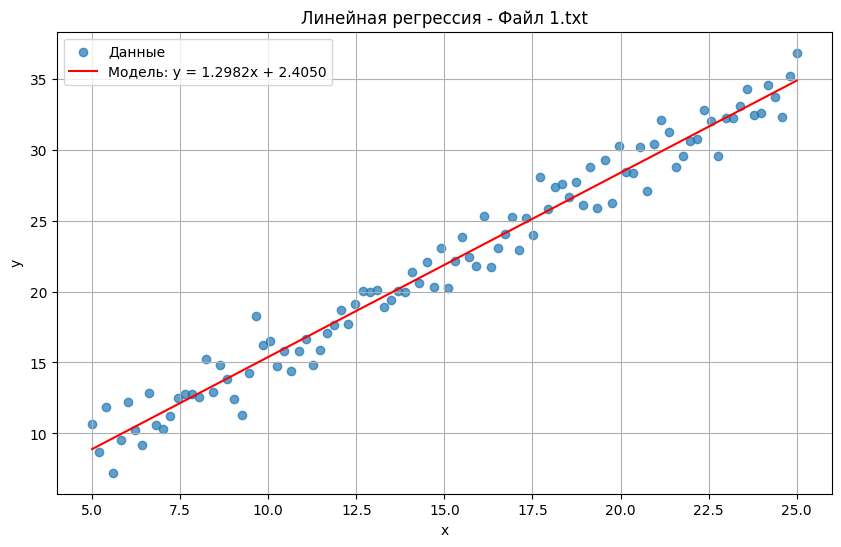

In [3]:
data = np.loadtxt('1.txt', delimiter=',')
x, y = data[:, 0], data[:, 1]
n = len(x)
# pearson corr coeff
r = pearson_corr(x, y)
print(f"Коэффициент корреляции Пирсона: r = {r:.4f}")
# check statistical significance pearson corr coeff
t_stat, t_crit, significant = t_test_corr(r, n)
print(f"t-статистика = {t_stat:.4f}, критическое значение = {t_crit:.4f}")
print(f"Корреляция {'значима' if significant else 'не значима'}")

# linear_regression
a, b = linreg_coef(x, y)
print(f"Линейная регрессия: y = {a:.4f}x + {b:.4f}")

# check adequacy of the model with Fischer criterion
F, F_crit, adequate = f_test_adequacy(x, y, a, b)
print(f"F-статистика = {F:.4f}, критическое значение = {F_crit:.4f}")
print(f"Модель {'адекватна' if adequate else 'не адекватна'}")

# check significance of coefficients
S_mod = np.sqrt(np.sum((y - (a*x + b))**2) / (n - 2))
T_a, T_b, t_crit, a_sig, b_sig, m_a, m_b = significance_coefs(x, y, a, b, S_mod)
print(f"Коэффициент a: t = {T_a:.4f}, {'значим' if a_sig else 'не значим'}")
print(f"Коэффициент b: t = {T_b:.4f}, {'значим' if b_sig else 'не значим'}")

# confidence intervals
a_ci, b_ci = conf_intervals(a, b, m_a, m_b, n)
print(f"a: [{a_ci[0]:.4f}, {a_ci[1]:.4f}]")
print(f"b: [{b_ci[0]:.4f}, {b_ci[1]:.4f}]")

# predict intervals
x_new, y_pred, pred_ci = pred_interval(x, y, a, b, delta_x=3)
print(f"Интервал прогноза для x = {x_new:.2f}:")
print(f"Точечный прогноз: {y_pred:.4f}")
print(f"Интервал: [{pred_ci[0]:.4f}, {pred_ci[1]:.4f}]")

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, label='Данные')
x_line = np.linspace(min(x), max(x), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, 'r-', label=f'Модель: y = {a:.4f}x + {b:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линейная регрессия - Файл 1.txt')
plt.legend()
plt.grid()
plt.show()

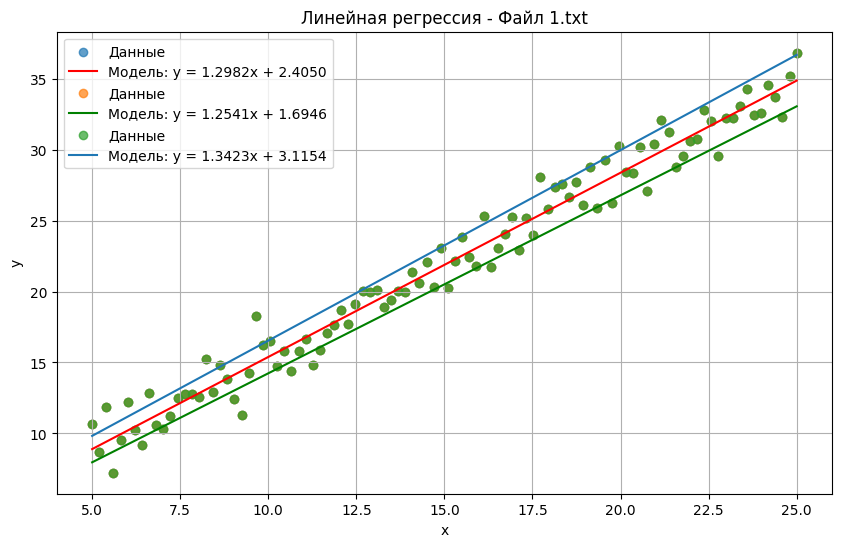

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, label='Данные')
x_line = np.linspace(min(x), max(x), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, 'r-', label=f'Модель: y = {a:.4f}x + {b:.4f}')
plt.scatter(x, y, alpha=0.7, label='Данные')
x2_line = np.linspace(min(x), max(x), 100)
y2_line = 1.2541 * x2_line + 1.6946
plt.plot(x2_line, y2_line, 'g-', label=f'Модель: y = {1.2541}x + {1.6946}')
plt.scatter(x, y, alpha=0.7, label='Данные')
x3_line = np.linspace(min(x), max(x), 100)
y3_line = 1.3423 * x3_line + 3.1154
plt.plot(x3_line, y3_line, label=f'Модель: y = {1.3423}x + {3.1154}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линейная регрессия - Файл 1.txt')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
data = np.loadtxt('2.txt', delimiter=',')
x, d1, d2, y = data[:, 0], data[:, 1], data[:, 2], data[:, 3]
# Chow-test 1
print("Тест Чоу для первого качественного признака:")
F1, F_crit1, significant1, coefs1 = chow_test(x, y, d1)
print(f"F-статистика = {F1:.4f}, критическое значение = {F_crit1:.4f}")
# Chow-test 2
print("\nТест Чоу для второго качественного признака:")
F2, F_crit2, significant2, coefs2 = chow_test(x, y, d2)
print(f"F-статистика = {F2:.4f}, критическое значение = {F_crit2:.4f}")

Тест Чоу для первого качественного признака:
F-статистика = 1101.6379, критическое значение = 3.0420

Тест Чоу для второго качественного признака:
F-статистика = 0.3423, критическое значение = 3.0420


Модель для d=0: y = 0.0595x + 2.4414
Модель для d=1: y = 0.4115x + -2.4370


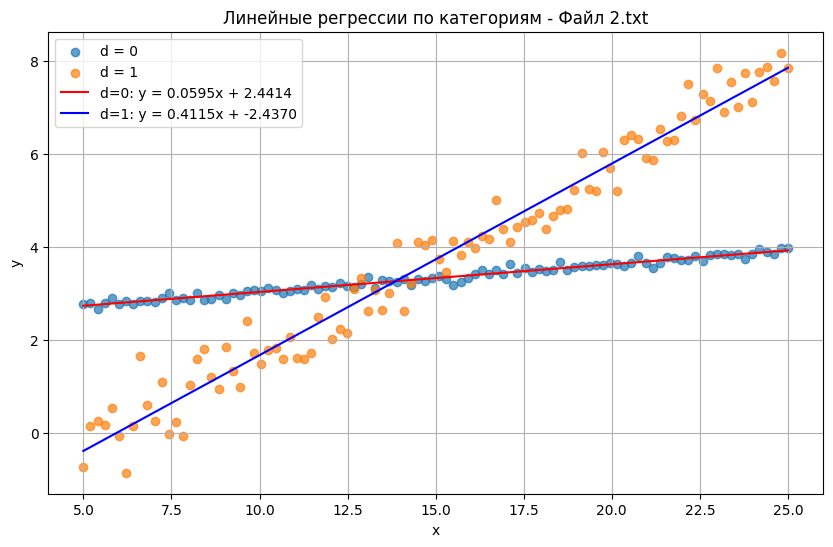

In [11]:
d = d1
x1, y1 = x[d == 0], y[d == 0]
x2, y2 = x[d == 1], y[d == 1]
a1, b1 = linreg_coef(x1, y1)
a2, b2 = linreg_coef(x2, y2)
print(f"Модель для d=0: y = {a1:.4f}x + {b1:.4f}")
print(f"Модель для d=1: y = {a2:.4f}x + {b2:.4f}")
# График
plt.figure(figsize=(10, 6))
plt.scatter(x1, y1, alpha=0.7, label='d = 0')
plt.scatter(x2, y2, alpha=0.7, label='d = 1')
x_line1 = np.linspace(min(x1), max(x1), 100)
x_line2 = np.linspace(min(x2), max(x2), 100)
plt.plot(x_line1, a1*x_line1 + b1, 'r-', label=f'd=0: y = {a1:.4f}x + {b1:.4f}')
plt.plot(x_line2, a2*x_line2 + b2, 'b-', label=f'd=1: y = {a2:.4f}x + {b2:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линейные регрессии по категориям - Файл 2.txt')
plt.legend()
plt.grid(True)
plt.show()

Линейная регрессия: y = 0.4467x + -12.7937
Коэффициент a: t = 1.2072, не значим
Коэффициент b: t = -2.1485, значим
Модель: F = 1.0045, не адекватна
Проверка на гетероскедастичность:
Тест Спирмена: r_s = 0.2916, t = 3.0176
Критическое значение: 1.9845
Гетероскедастичность присутствует
Тест Гольдфельда-Квандта: F = 3.5517
Критическое значение: 1.7430
Гетероскедастичность присутствует


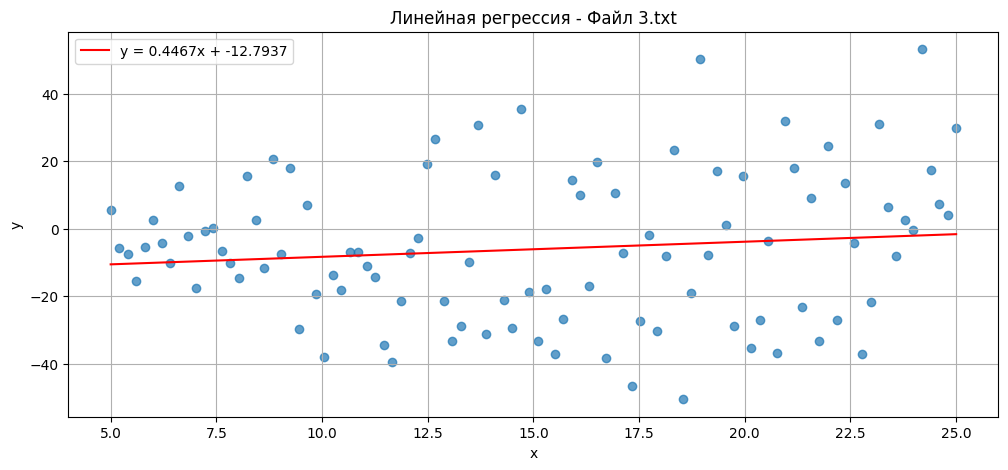

In [7]:
data = np.loadtxt('3.txt', delimiter=',')
x, y = data[:, 0], data[:, 1]
n = len(x)
a, b = linreg_coef(x, y)
print(f"Линейная регрессия: y = {a:.4f}x + {b:.4f}")
# значимость и адекватность
S_mod = np.sqrt(np.sum((y - (a*x + b))**2) / (n - 2))
T_a, T_b, t_crit, a_sig, b_sig, m_a, m_b = significance_coefs(x, y, a, b, S_mod)
F, F_crit, adequate = f_test_adequacy(x, y, a, b)
print(f"Коэффициент a: t = {T_a:.4f}, {'значим' if a_sig else 'не значим'}")
print(f"Коэффициент b: t = {T_b:.4f}, {'значим' if b_sig else 'не значим'}")
print(f"Модель: F = {F:.4f}, {'адекватна' if adequate else 'не адекватна'}")
# тесты на гетероскедастичность
print(f"Проверка на гетероскедастичность:")
# Spearmen test
r_s, t_s, t_crit_s, hetero_spearman = spearman_test(x, y, a, b)
print(f"Тест Спирмена: r_s = {r_s:.4f}, t = {t_s:.4f}")
print(f"Критическое значение: {t_crit_s:.4f}")
print(f"Гетероскедастичность {'присутствует' if hetero_spearman else 'отсутствует'}")
# GK-test
F_gq, F_crit_gq, hetero_gq = goldfeld_quandt_test(x, y, a, b)
print(f"Тест Гольдфельда-Квандта: F = {F_gq:.4f}")
print(f"Критическое значение: {F_crit_gq:.4f}")
print(f"Гетероскедастичность {'присутствует' if hetero_gq else 'отсутствует'}")
plt.figure(figsize=(12, 5))
plt.scatter(x, y, alpha=0.7)
x_line = np.linspace(min(x), max(x), 100)
plt.plot(x_line, a*x_line + b, 'r-', label=f'y = {a:.4f}x + {b:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линейная регрессия - Файл 3.txt')
plt.legend()
plt.grid(True)